# 03 — Подтверждение отбоя: голое касание vs wick vs close-back-inside

nb02 показал: голая близость к уровню = 0 edge. Гипотеза: edge живёт в **подтверждённом
отбое**. Держим метод-уровень фиксированным (clusters, swings_k10), меняем триггер:

- **bare** — просто касание (база из nb02).
- **wick** — бар достал зону, но закрылся в дальней трети (длинная тень = откуп/слив).
- **cbi** — бар прошил уровень, но закрылся обратно за него (ложный пробой).

Всё известно на close бара t → вход на close[t]. signed fwd-доходность vs baseline-дрейф.

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import *
import pandas as pd

full = [s for s in sorted(p.name for p in loader.DATA_ROOT.iterdir() if p.is_dir())
        if len(list((loader.DATA_ROOT / s).glob("*.parquet"))) >= 28]
UNIV = full[::3][:50]
START, END, TF = "2024-01-01", "2025-01-01", "1h"
TOL = 0.0015; CD = 6; LIFE = 720; H = [4, 12, 24]; HMAX = 24
print(len(UNIV), "symbols")

47 symbols


In [2]:
def pivots(df, k):
    h = df["high"].to_numpy(); l = df["low"].to_numpy(); n = len(df)
    hi = np.zeros(n, bool); lo = np.zeros(n, bool)
    for i in range(k, n - k):
        wH = h[i - k:i + k + 1]; wL = l[i - k:i + k + 1]
        if h[i] == wH.max() and (wH == h[i]).sum() == 1: hi[i] = True
        if l[i] == wL.min() and (wL == l[i]).sum() == 1: lo[i] = True
    return hi, lo

def pivot_segments(df, k, life=LIFE):
    hi, lo = pivots(df, k); n = len(df)
    h = df["high"].to_numpy(); l = df["low"].to_numpy(); segs = []
    for i in np.where(hi)[0]: c = i + k; segs.append((h[i], c, min(c + life, n)))
    for i in np.where(lo)[0]: c = i + k; segs.append((l[i], c, min(c + life, n)))
    return segs

def cluster_segments(df, k=10, R=24, life=LIFE, tol=0.006, mint=3):
    hi, lo = pivots(df, k); n = len(df)
    h = df["high"].to_numpy(); l = df["low"].to_numpy(); conf = []
    for i in np.where(hi)[0]: conf.append((i + k, h[i]))
    for i in np.where(lo)[0]: conf.append((i + k, l[i]))
    conf = np.array(sorted(conf)) if conf else np.empty((0, 2)); segs = []
    for r in range(k, n, R):
        if len(conf) == 0: break
        m = (conf[:, 0] <= r) & (conf[:, 0] > r - life); px = np.sort(conf[m, 1])
        if len(px) < mint: continue
        cl = [[px[0]]]
        for x in px[1:]:
            if (x - cl[-1][0]) / cl[-1][0] <= tol: cl[-1].append(x)
            else: cl.append([x])
        for c in cl:
            if len(c) >= mint: segs.append((float(np.mean(c)), r, min(r + R, n)))
    return segs

In [3]:
def candidate_touches(df, segs, tol=TOL):
    """All approach-touches as (t, side, L). One nearest level per (t, side)."""
    c = df["close"].to_numpy(); h = df["high"].to_numpy(); l = df["low"].to_numpy()
    best = {}
    for L, a, b in segs:
        a = max(a, 1)
        for t in range(a, b):
            if c[t - 1] < L * (1 - tol) and h[t] >= L * (1 - tol):
                d = abs(h[t] - L) / L; key = (t, "res")
                if key not in best or d < best[key][1]: best[key] = (L, d)
            elif c[t - 1] > L * (1 + tol) and l[t] <= L * (1 + tol):
                d = abs(l[t] - L) / L; key = (t, "sup")
                if key not in best or d < best[key][1]: best[key] = (L, d)
    return [(t, side, L) for (t, side), (L, d) in best.items()]

def trigger_ok(o, h, l, c, side, L, kind, tol=TOL):
    rng = max(h - l, 1e-12)
    if side == "res":
        if kind == "bare": return True
        if kind == "wick": return c < L * (1 - tol) and c <= l + 0.33 * rng
        if kind == "cbi":  return h > L * (1 + tol) and c < L
    else:
        if kind == "bare": return True
        if kind == "wick": return c > L * (1 + tol) and c >= h - 0.33 * rng
        if kind == "cbi":  return l < L * (1 - tol) and c > L
    return False

def dedup(ev, cd=CD):
    ev = sorted(ev); out = []; last = -10**9
    for t, side, L in ev:
        if t - last >= cd: out.append((t, side, L)); last = t
    return out

In [4]:
FINDERS = {"swings_k10": lambda df: pivot_segments(df, k=10),
           "clusters":   lambda df: cluster_segments(df, k=10)}
TRIGGERS = ["bare", "wick", "cbi"]

rows = []; drift_sum = {h: 0.0 for h in H}; drift_cnt = {h: 0 for h in H}
for si, sym in enumerate(UNIV):
    df = ohlcv(sym, START, END, TF)
    if len(df) < HMAX + 50: continue
    o = df["open"].to_numpy(); h_ = df["high"].to_numpy(); l_ = df["low"].to_numpy(); c = df["close"].to_numpy(); n = len(df)
    for hh in H:
        r = c[hh:] / c[:-hh] - 1.0; drift_sum[hh] += float(np.nansum(r)); drift_cnt[hh] += int(np.isfinite(r).sum())
    for fname, build in FINDERS.items():
        cand = candidate_touches(df, build(df))
        for trig in TRIGGERS:
            sel = [(t, side, L) for (t, side, L) in cand
                   if trigger_ok(o[t], h_[t], l_[t], c[t], side, L, trig)]
            for t, side, L in dedup(sel):
                if t + HMAX >= n: continue
                row = dict(finder=fname, trigger=trig, side=side)
                for hh in H:
                    rr = c[t + hh] / c[t] - 1.0
                    row[f"r{hh}"] = rr if side == "sup" else -rr
                rows.append(row)
    if (si + 1) % 15 == 0: print(f"  {si+1}/{len(UNIV)}")

ev = pd.DataFrame(rows); drift = {h: drift_sum[h] / drift_cnt[h] for h in H}
print("events:", len(ev), "| drift%:", {h: round(drift[h]*100,3) for h in H})

  15/47


  30/47


  45/47


events: 160788 | drift%: {4: 0.03, 12: 0.09, 24: 0.176}


In [5]:
def edge_rows(df_ev):
    recs = []
    for (f, trig), g in df_ev.groupby(["finder", "trigger"]):
        rec = {"finder": f, "trigger": trig, "n": len(g)}
        for h in H:
            e = 0.0
            for side, gg in g.groupby("side"):
                b = drift[h] if side == "sup" else -drift[h]
                e += (gg[f"r{h}"].mean() - b) * len(gg)
            rec[f"edge{h}%"] = e / len(g) * 100
        rec["raw12%"] = g["r12"].mean() * 100
        rec["ms12"] = g["r12"].mean() / g["r12"].std() if g["r12"].std() > 0 else np.nan
        recs.append(rec)
    return pd.DataFrame(recs).set_index(["finder", "trigger"])

tbl = edge_rows(ev); tbl.round(3)

n  edge4%  edge12%  edge24%  raw12%   ms12
finder     trigger                                                
clusters   bare     17731   0.016    0.011    0.004   0.012  0.003
           cbi       8794   0.033    0.025    0.032   0.033  0.009
           wick      8886   0.036    0.016    0.039   0.024  0.007
swings_k10 bare     55782   0.010    0.020    0.008   0.005  0.001
           cbi      32457   0.009   -0.006   -0.012  -0.003 -0.001
           wick     37138  -0.006   -0.032    0.029  -0.027 -0.007

[saved] notebooks\levels\_out\03_triggers.png


WindowsPath('C:/projects/researchlab/notebooks/levels/_out/03_triggers.png')

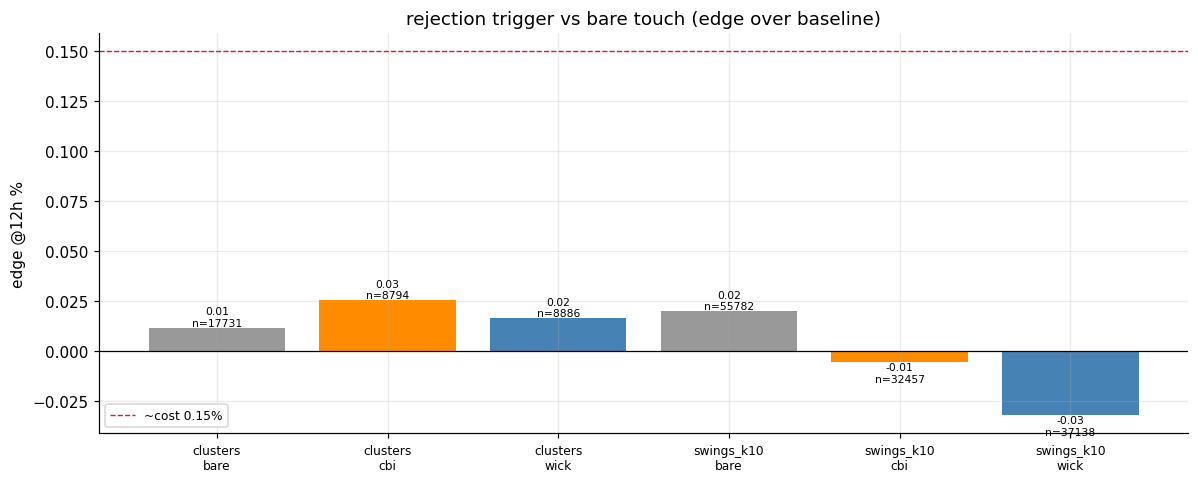

In [6]:
fig, ax = plt.subplots(figsize=(11, 4.5))
lab = [f"{f}\n{t}" for f, t in tbl.index]
colors = ["0.6" if t == "bare" else ("steelblue" if t == "wick" else "darkorange") for f, t in tbl.index]
ax.bar(range(len(tbl)), tbl["edge12%"], color=colors)
ax.set_xticks(range(len(tbl))); ax.set_xticklabels(lab, fontsize=8)
ax.axhline(0, color="k", lw=0.8); ax.axhline(0.15, color="crimson", ls="--", lw=0.9, label="~cost 0.15%")
ax.set_ylabel("edge @12h %"); ax.set_title("rejection trigger vs bare touch (edge over baseline)"); ax.legend(fontsize=8)
for i, v in enumerate(tbl["edge12%"]): ax.text(i, v, f"{v:.2f}\nn={int(tbl['n'].iloc[i])}", ha="center", va="bottom" if v>=0 else "top", fontsize=7)
show("03_triggers")

## Итог

Сравниваем: поднимает ли подтверждение (wick / cbi) edge над голым касанием и над
издержками. Если да — на каком финдере сильнее и при каком n. Если снова ноль —
разворот от уровней как класс под вопросом, и надо думать о контексте (тренд/режим,
глубина подхода), а не о форме свечи.